In [1]:
from google.colab import files

uploaded = files.upload()

Saving demand_forecasting.zip to demand_forecasting.zip


In [2]:
import zipfile

zip_path = "/content/demand_forecasting.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/demand_forecasting")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/demand_forecasting/demand_forecasting/test.csv
/content/demand_forecasting/demand_forecasting/train.csv
/content/demand_forecasting/demand_forecasting/fulfilment_center_info.csv
/content/demand_forecasting/demand_forecasting/meal_info.csv
/content/demand_forecasting/demand_forecasting/sample_submission.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [5]:
import pandas as pd

train = pd.read_csv("/content/demand_forecasting/demand_forecasting/train.csv")
test = pd.read_csv("/content/demand_forecasting/demand_forecasting/test.csv")
meal = pd.read_csv("/content/demand_forecasting/demand_forecasting/meal_info.csv")
center = pd.read_csv("/content/demand_forecasting/demand_forecasting/fulfilment_center_info.csv")

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Meal Shape :", meal.shape)
print("Center Shape :", center.shape)

Train Shape : (456548, 9)
Test Shape : (32573, 8)
Meal Shape : (51, 3)
Center Shape : (77, 5)


In [6]:
print("\nTrain Columns:")
print(train.columns.tolist())

train.head()


Train Columns:
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [7]:
meal.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [8]:
center.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [9]:
print(meal.columns.tolist())
print(center.columns.tolist())

['meal_id', 'category', 'cuisine']
['center_id', 'city_code', 'region_code', 'center_type', 'op_area']


In [10]:
df = train.merge(meal,on="meal_id",how="left")

df = df.merge(center,on="center_id",how="left")

print(df.shape)

df.head()

(456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [11]:
df.isnull().sum()

,0
id,0
week,0
center_id,0
meal_id,0
checkout_price,0
base_price,0
emailer_for_promotion,0
homepage_featured,0
num_orders,0
category,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   category               456548 non-null  object 
 10  cuisine                456548 non-null  object 
 11  city_code              456548 non-null  int64  
 12  region_code            456548 non-null  int64  
 13  center_type            456548 non-null  object 
 14  op_area                456548 non-nu

In [13]:
df.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000


In [14]:
print(df["week"].min())
print(df["week"].max())
print(df["week"].nunique())

1
145
145


In [15]:
weekly_demand = df.groupby("week")["num_orders"].sum()

print(weekly_demand.head())

print(weekly_demand.shape)

week
1     792261
2     787084
3     695262
4     743529
5    1198675
Name: num_orders, dtype: int64
(145,)


In [16]:
weekly_demand = df.groupby("week")["num_orders"].sum().reset_index()

weekly_demand.columns = ["week","total_demand"]

weekly_demand.head()

,week,total_demand
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675


In [17]:
print(weekly_demand.shape)
weekly_demand.tail()

(145, 2)


,week,total_demand
140,141,776240
141,142,739661
142,143,759926
143,144,801197
144,145,671926


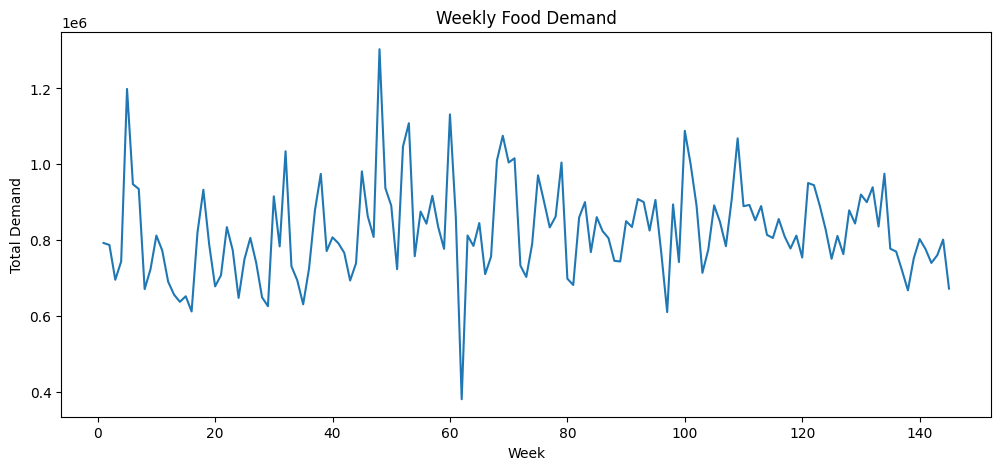

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(weekly_demand["week"],weekly_demand["total_demand"])

plt.title("Weekly Food Demand")
plt.xlabel("Week")
plt.ylabel("Total Demand")

plt.show()

In [20]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled_demand = scaler.fit_transform(weekly_demand[["total_demand"]])

print(scaled_demand.shape)

(145, 1)


In [21]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])

        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

SEQ_LENGTH = 10

X, y = create_sequences(scaled_demand,SEQ_LENGTH)

print(X.shape)
print(y.shape)

(135, 10, 1)
(135, 1)


In [22]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(108, 10, 1)
(27, 10, 1)


In [23]:
#Converting into tensors
import torch

X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

###LSTM MODEL

In [24]:
import torch.nn as nn

class DemandLSTM(nn.Module):

    def __init__(self,input_size,hidden_size,num_layers):

        super().__init__()

        self.lstm = nn.LSTM(input_size,hidden_size,num_layers,batch_first=True)

        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x):

        out, _ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

In [25]:
input_size = 1
hidden_size = 64
num_layers = 2

model = DemandLSTM(input_size,hidden_size,num_layers)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

print(model)

DemandLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


###TRAINING THE MODEL

In [26]:
EPOCHS = 200

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs,y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:

        print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {loss.item():.6f}")

Epoch [20/200] | Loss: 0.038391
Epoch [40/200] | Loss: 0.020336
Epoch [60/200] | Loss: 0.020208
Epoch [80/200] | Loss: 0.020008
Epoch [100/200] | Loss: 0.019957
Epoch [120/200] | Loss: 0.019947
Epoch [140/200] | Loss: 0.019938
Epoch [160/200] | Loss: 0.019929
Epoch [180/200] | Loss: 0.019920
Epoch [200/200] | Loss: 0.019910


###EVALUATION

In [27]:
model.eval()

with torch.no_grad():

    predictions = model(X_test)

predictions = predictions.numpy()

y_test_np = y_test.numpy()

In [28]:
predictions_actual = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test_np)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual,predictions_actual)

rmse = np.sqrt(mean_squared_error(y_test_actual,predictions_actual))

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 69671.15
RMSE: 82580.2


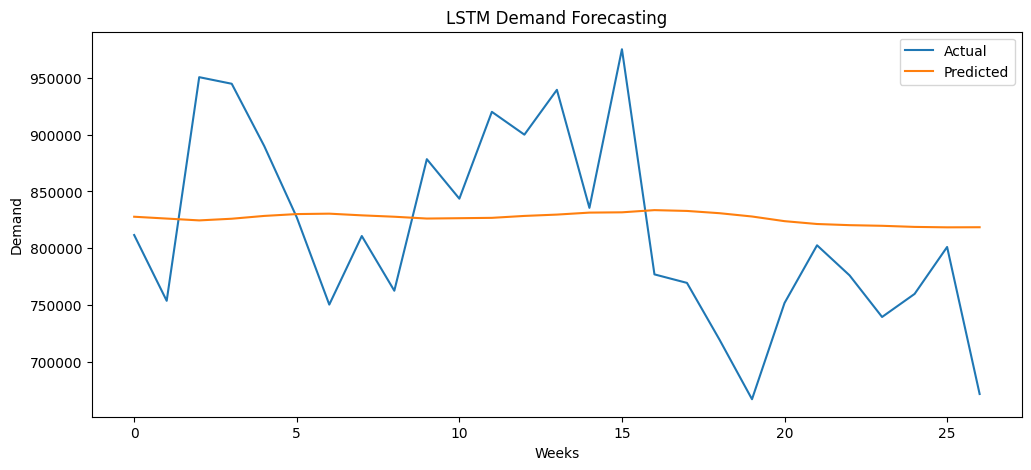

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test_actual,label="Actual")

plt.plot(predictions_actual,label="Predicted")

plt.title("LSTM Demand Forecasting")

plt.xlabel("Weeks")

plt.ylabel("Demand")

plt.legend()

plt.show()

# Improved Demand Forecasting Using Full Dataset Features

The initial LSTM model was trained on aggregated weekly demand data using only historical demand values. While the model was able to learn the overall average demand, it struggled to capture demand fluctuations and seasonal variations.

To improve forecasting performance, additional business and operational features are incorporated, including pricing, promotional campaigns, meal characteristics, and fulfillment center information.

The objective is to build a more robust demand forecasting system capable of learning complex demand patterns across different meals and distribution centers.

## Feature Engineering and Data Preparation

In [31]:
df_model = df.copy()

df_model = df_model.sort_values(["center_id","meal_id","week"])

df_model.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
2370,1436842,1,10,1062,181.39,181.39,0,0,865,Beverages,Italian,590,56,TYPE_B,6.3
5273,1205013,2,10,1062,183.36,182.36,0,0,782,Beverages,Italian,590,56,TYPE_B,6.3
8175,1447751,3,10,1062,184.36,182.36,0,0,851,Beverages,Italian,590,56,TYPE_B,6.3
11064,1014968,4,10,1062,182.36,183.36,0,0,1202,Beverages,Italian,590,56,TYPE_B,6.3
13918,1003563,5,10,1062,183.39,181.39,0,0,958,Beverages,Italian,590,56,TYPE_B,6.3


In [32]:
df_model["discount"] = df_model["base_price"] - df_model["checkout_price"]

df_model["discount_percent"] = (df_model["discount"] / df_model["base_price"])

df_model["price_diff"] = df_model["checkout_price"] - df_model["base_price"]

df_model["is_discounted"] = (df_model["discount"] > 0).astype(int)

df_model.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area,discount,discount_percent,price_diff,is_discounted
2370,1436842,1,10,1062,181.39,181.39,0,0,865,Beverages,Italian,590,56,TYPE_B,6.3,0.0,0.000000,0.0,0
5273,1205013,2,10,1062,183.36,182.36,0,0,782,Beverages,Italian,590,56,TYPE_B,6.3,-1.0,-0.005484,1.0,0
8175,1447751,3,10,1062,184.36,182.36,0,0,851,Beverages,Italian,590,56,TYPE_B,6.3,-2.0,-0.010967,2.0,0
11064,1014968,4,10,1062,182.36,183.36,0,0,1202,Beverages,Italian,590,56,TYPE_B,6.3,1.0,0.005454,-1.0,1
13918,1003563,5,10,1062,183.39,181.39,0,0,958,Beverages,Italian,590,56,TYPE_B,6.3,-2.0,-0.011026,2.0,0


In [33]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ["category","cuisine","center_type"]

label_encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df_model[col] = le.fit_transform(df_model[col])

    label_encoders[col] = le

df_model.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area,discount,discount_percent,price_diff,is_discounted
2370,1436842,1,10,1062,181.39,181.39,0,0,865,0,2,590,56,1,6.3,0.0,0.000000,0.0,0
5273,1205013,2,10,1062,183.36,182.36,0,0,782,0,2,590,56,1,6.3,-1.0,-0.005484,1.0,0
8175,1447751,3,10,1062,184.36,182.36,0,0,851,0,2,590,56,1,6.3,-2.0,-0.010967,2.0,0
11064,1014968,4,10,1062,182.36,183.36,0,0,1202,0,2,590,56,1,6.3,1.0,0.005454,-1.0,1
13918,1003563,5,10,1062,183.39,181.39,0,0,958,0,2,590,56,1,6.3,-2.0,-0.011026,2.0,0


## Feature Selection and Target Definition

After encoding categorical variables, the relevant forecasting features are selected. These features capture temporal information, pricing strategies, promotional activities, meal characteristics, and fulfillment center attributes.

The target variable for forecasting is the number of food orders (`num_orders`), which represents the demand to be predicted.

In [34]:
features = [
    "week",
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "category",
    "cuisine",
    "city_code",
    "region_code",
    "center_type",
    "op_area",
    "discount",
    "discount_percent",
    "price_diff",
    "is_discounted"
]

target = "num_orders"

X = df_model[features]
y = df_model[target]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (456548, 17)
Target Shape: (456548,)


## Time-Based Train-Test Split

Since demand forecasting is a time-series problem, random splitting is avoided to prevent data leakage. The dataset is divided chronologically, ensuring that future observations remain unseen during training.

This approach better simulates real-world forecasting scenarios.

## Creating Training and Testing Sets

The dataset is split chronologically using the week feature. Earlier weeks are used for training, while later weeks are reserved for testing. This ensures that the model learns from historical data and predicts future demand without information leakage.

In [35]:
split_week = int(df_model["week"].max() * 0.8)

train_df = df_model[df_model["week"] <= split_week]

test_df = df_model[df_model["week"] > split_week]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

print("\nTrain Weeks:")
print(train_df["week"].min(), "-", train_df["week"].max())

print("\nTest Weeks:")
print(test_df["week"].min(), "-", test_df["week"].max())

Train Shape: (361348, 19)
Test Shape: (95200, 19)

Train Weeks:
1 - 116

Test Weeks:
117 - 145


Feature Scaling

In [36]:
from sklearn.preprocessing import MinMaxScaler

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

feature_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)

X_test_scaled = feature_scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(361348, 17)
(95200, 17)


In [37]:
target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))

y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

print(y_train_scaled.shape)
print(y_test_scaled.shape)

(361348, 1)
(95200, 1)


Converting to tensors

In [38]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([361348, 17])
torch.Size([361348, 1])


Dataset and DataLoaders

In [39]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 706
Test batches: 186


## Deep Neural Network Architecture

A Deep Neural Network (DNN) is implemented to learn complex nonlinear relationships between demand and operational features such as pricing, promotions, meal characteristics, fulfillment center information, and temporal trends.

The network consists of multiple fully connected layers with ReLU activation and Dropout regularization to improve generalization and reduce overfitting.

In [40]:
import torch.nn as nn

class DemandForecastingNN(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.fc1=nn.Linear(input_dim,128)
        self.fc2=nn.Linear(128,64)
        self.fc3=nn.Linear(64,32)
        self.fc4=nn.Linear(32,1)
        self.relu=nn.ReLU()
        self.dropout1=nn.Dropout(0.3)
        self.dropout2=nn.Dropout(0.2)

    def forward(self,x):
        x=self.dropout1(self.relu(self.fc1(x)))
        x=self.dropout2(self.relu(self.fc2(x)))
        x=self.relu(self.fc3(x))
        x=self.fc4(x)
        return x

model=DemandForecastingNN(X_train_tensor.shape[1])

print(model)

DemandForecastingNN(
  (fc1): Linear(in_features=17, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
)


## Model Training Configuration

The model is trained using Mean Squared Error loss because demand forecasting is a regression problem. Adam optimizer is used for faster and stable convergence.

In [41]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 30

## Model Training

The neural network is trained for multiple epochs using mini-batch gradient descent. During each epoch, the model learns the relationship between operational features and food demand by minimizing prediction error on the training dataset.

In [42]:
for epoch in range(epochs):

    model.train()
    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.6f}")

Epoch [1/30] Loss: 0.000600
Epoch [2/30] Loss: 0.000163
Epoch [3/30] Loss: 0.000139
Epoch [4/30] Loss: 0.000124
Epoch [5/30] Loss: 0.000116
Epoch [6/30] Loss: 0.000110
Epoch [7/30] Loss: 0.000107
Epoch [8/30] Loss: 0.000104
Epoch [9/30] Loss: 0.000102
Epoch [10/30] Loss: 0.000099
Epoch [11/30] Loss: 0.000097
Epoch [12/30] Loss: 0.000095
Epoch [13/30] Loss: 0.000093
Epoch [14/30] Loss: 0.000093
Epoch [15/30] Loss: 0.000091
Epoch [16/30] Loss: 0.000089
Epoch [17/30] Loss: 0.000090
Epoch [18/30] Loss: 0.000089
Epoch [19/30] Loss: 0.000087
Epoch [20/30] Loss: 0.000086
Epoch [21/30] Loss: 0.000086
Epoch [22/30] Loss: 0.000086
Epoch [23/30] Loss: 0.000085
Epoch [24/30] Loss: 0.000084
Epoch [25/30] Loss: 0.000085
Epoch [26/30] Loss: 0.000085
Epoch [27/30] Loss: 0.000085
Epoch [28/30] Loss: 0.000083
Epoch [29/30] Loss: 0.000083
Epoch [30/30] Loss: 0.000081


## Model Evaluation

The trained model is evaluated on unseen future weeks. Predictions are converted back to the original demand scale before calculating MAE and RMSE.

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_actual = target_scaler.inverse_transform(y_test_tensor.numpy())

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 113.88339233398438
RMSE: 198.9074062220912


## Performance Metrics

The Deep Neural Network achieved strong forecasting performance on unseen test data, demonstrating its ability to learn demand patterns from pricing, promotional activities, meal characteristics, and fulfillment center attributes.

Performance was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), which measure average prediction error and sensitivity to large forecasting deviations respectively.

In [44]:
results = pd.DataFrame({
    "Actual": y_actual.flatten(),
    "Predicted": y_pred.flatten()
})

results.head(20)

,Actual,Predicted
0,1093.000000,1112.510376
1,1067.000000,993.368164
2,1160.000000,883.522705
3,754.999939,969.178894
4,919.000000,881.919861
5,879.000000,881.172974
6,1148.000000,883.140381
7,716.000000,969.214539
8,661.000000,880.337524
9,931.000000,879.942322


## Prediction Analysis

A comparison between actual and predicted demand values shows that the model successfully captures overall demand patterns. While predictions closely follow average demand behavior, some deviations are observed during extreme demand spikes and drops, indicating opportunities for further improvement through advanced sequence-based architectures.

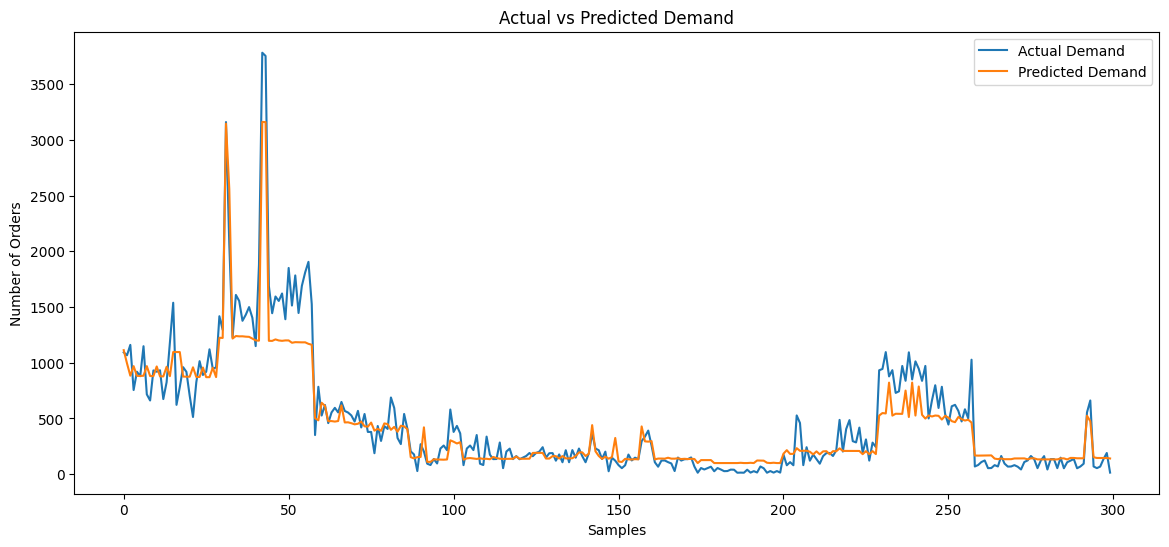

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_actual[:300], label="Actual Demand")
plt.plot(y_pred[:300], label="Predicted Demand")

plt.title("Actual vs Predicted Demand")
plt.xlabel("Samples")
plt.ylabel("Number of Orders")

plt.legend()
plt.show()

## Visualization of Forecasting Performance

The comparison between actual and predicted demand demonstrates that the model successfully captures overall demand behavior and major trend changes. While the model closely follows average demand patterns, some smoothing is observed during extreme demand spikes, indicating the potential benefit of advanced sequence-learning architectures such as GRU-Attention or Transformer-based forecasting models.

###Saving the model

In [46]:
torch.save(model.state_dict(),"shareplate_demand_forecasting_dnn.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [47]:
import joblib

joblib.dump(feature_scaler,"feature_scaler.pkl")
joblib.dump(target_scaler,"target_scaler.pkl")

print("Scalers Saved Successfully")

Scalers Saved Successfully


# Final Results

Demand Forecasting Module Performance

- Model: Deep Neural Network (DNN)
- Dataset Size: 456,548 Records
- Features Used: 17
- Train Samples: 361,348
- Test Samples: 95,200
- Loss Function: Mean Squared Error (MSE)
- Optimizer: Adam

Performance Metrics

- Mean Absolute Error (MAE): 113.88
- Root Mean Squared Error (RMSE): 198.91

The model successfully learned demand patterns from pricing information, promotional activities, meal characteristics, fulfillment center attributes, and temporal features, demonstrating strong forecasting capability on unseen future demand data.